# Final Project Planning Lab
**Savannah Wallis**




### 1. Dataset Overview
https://archive.ics.uci.edu/dataset/938/regensburg+pediatric+appendicitis

This dataset is from the UC Irvine Machine Learning Repository. It contains data donated from a German hospital, in which children with abdominal pain between 2016 and 2021 were admitted. Predictor variables include patient demographics, symptoms, and tests. The binary target is whether or not the child had appendicitis.

### 4. Dataset Purpose

This dataset was selected because I have a professional interest in children's health. Understanding predictors of appendicitis could save lives. It was also selected because it appropriately satisfies all requirements of the final project dataset. It has 782 observations, is a binary classification (Appendicitis Diagnosis), and has 57 predictors.

### 3. Explore the Data

I will start by doing an initial exploration of the data. For example a head, shape, column names, data types, and description of variables.

In [17]:
# Packages
import pandas as pd

#Load data
df = pd.read_excel("app_data.xlsx", sheet_name=0)

# First five rows
display(df.head())

,Age,BMI,Sex,Height,Weight,Length_of_Stay,Management,Severity,Diagnosis_Presumptive,Diagnosis,...,Abscess_Location,Pathological_Lymph_Nodes,Lymph_Nodes_Location,Bowel_Wall_Thickening,Conglomerate_of_Bowel_Loops,Ileus,Coprostasis,Meteorism,Enteritis,Gynecological_Findings
0,12.68,16.9,female,148.0,37.0,3.0,conservative,uncomplicated,appendicitis,appendicitis,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14.10,31.9,male,147.0,69.5,2.0,conservative,uncomplicated,appendicitis,no appendicitis,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,NaN,NaN
2,14.14,23.3,female,163.0,62.0,4.0,conservative,uncomplicated,appendicitis,no appendicitis,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yes,yes,NaN
3,16.37,20.6,female,165.0,56.0,3.0,conservative,uncomplicated,appendicitis,no appendicitis,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,yes,NaN
4,11.08,16.9,female,163.0,45.0,3.0,conservative,uncomplicated,appendicitis,appendicitis,...,NaN,yes,reUB,NaN,NaN,NaN,NaN,NaN,yes,NaN


In [18]:
# Shape
print(df.shape)

# Column names
print(df.columns)

# Data types
print(df.dtypes)

# Info overview
print(df.info)

(782, 58)
Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Length_of_Stay', 'Management',
       'Severity', 'Diagnosis_Presumptive', 'Diagnosis', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_on_US', 'Appendix_Diameter',
       'Migratory_Pain', 'Lower_Right_Abd_Pain',
       'Contralateral_Rebound_Tenderness', 'Coughing_Pain', 'Nausea',
       'Loss_of_Appetite', 'Body_Temperature', 'WBC_Count',
       'Neutrophil_Percentage', 'Segmented_Neutrophils', 'Neutrophilia',
       'RBC_Count', 'Hemoglobin', 'RDW', 'Thrombocyte_Count',
       'Ketones_in_Urine', 'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria',
       'Stool', 'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness',
       'US_Performed', 'US_Number', 'Free_Fluids', 'Appendix_Wall_Layers',
       'Target_Sign', 'Appendicolith', 'Perfusion', 'Perforation',
       'Surrounding_Tissue_Reaction', 'Appendicular_Abscess',
       'Abscess_Location', 'Pathological_Lymph_Nodes', 'Lymph_Nodes_Location',
   

The exploration has found everything stated in the documentation to be accurate. The shape, missing values, and target are all as described.

### 4. EDA
The next step is to do some basic statistical analysis to understand the data better. I looked at a summary statistics table and also a couple plots. The bar chart of classes will help determine if class imbalance is occurring (important for machine learning). A correlation heatmap is also important for understanding how the numeric variables correlate.

,Age,BMI,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP,US_Number
count,781.000000,755.000000,756.000000,779.000000,778.000000,730.000000,730.000000,498.000000,775.000000,776.000000,679.000000,54.000000,764.000000,764.000000,756.000000,764.000000,771.000000,760.000000
mean,11.346483,18.906916,148.017460,43.172542,4.284062,5.921918,5.253425,7.762651,37.404516,12.670683,71.791163,64.929630,4.799490,13.380497,13.180291,285.252618,31.387899,425.515789
std,3.529979,4.385252,19.732016,17.390984,2.574057,2.155972,1.958456,2.536671,0.903678,5.366525,14.463656,15.085025,0.499012,1.393271,4.538774,72.494373,57.433588,271.585211
min,0.000000,7.827983,53.000000,3.960000,1.000000,0.000000,0.000000,2.700000,26.900000,2.600000,27.200000,32.000000,3.620000,8.200000,11.200000,91.000000,0.000000,1.000000
25%,9.200000,15.725294,137.000000,29.500000,3.000000,4.000000,4.000000,6.000000,36.800000,8.200000,61.400000,54.500000,4.537500,12.600000,12.300000,236.000000,1.000000,198.750000
50%,11.438741,18.062284,149.650000,41.400000,3.000000,6.000000,5.000000,7.500000,37.200000,12.000000,75.500000,64.500000,4.780000,13.300000,12.700000,276.000000,7.000000,398.500000
75%,14.099932,21.179011,163.000000,54.000000,5.000000,8.000000,7.000000,9.100000,37.900000,16.200000,83.600000,77.500000,5.020000,14.000000,13.300000,330.000000,33.000000,613.250000
max,18.360000,38.156221,192.000000,103.000000,28.000000,10.000000,10.000000,17.000000,40.200000,37.700000,97.700000,91.000000,14.000000,36.000000,86.900000,708.000000,365.000000,992.000000


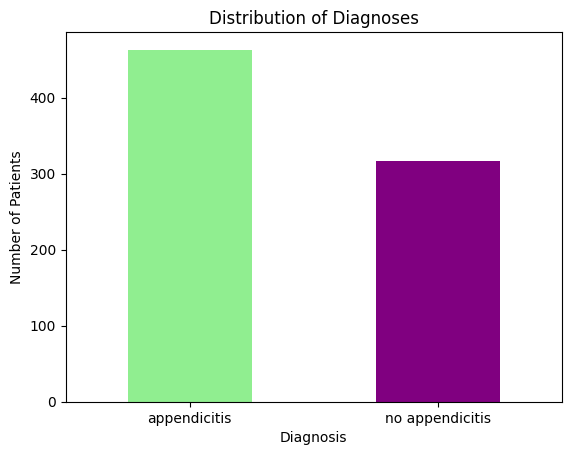

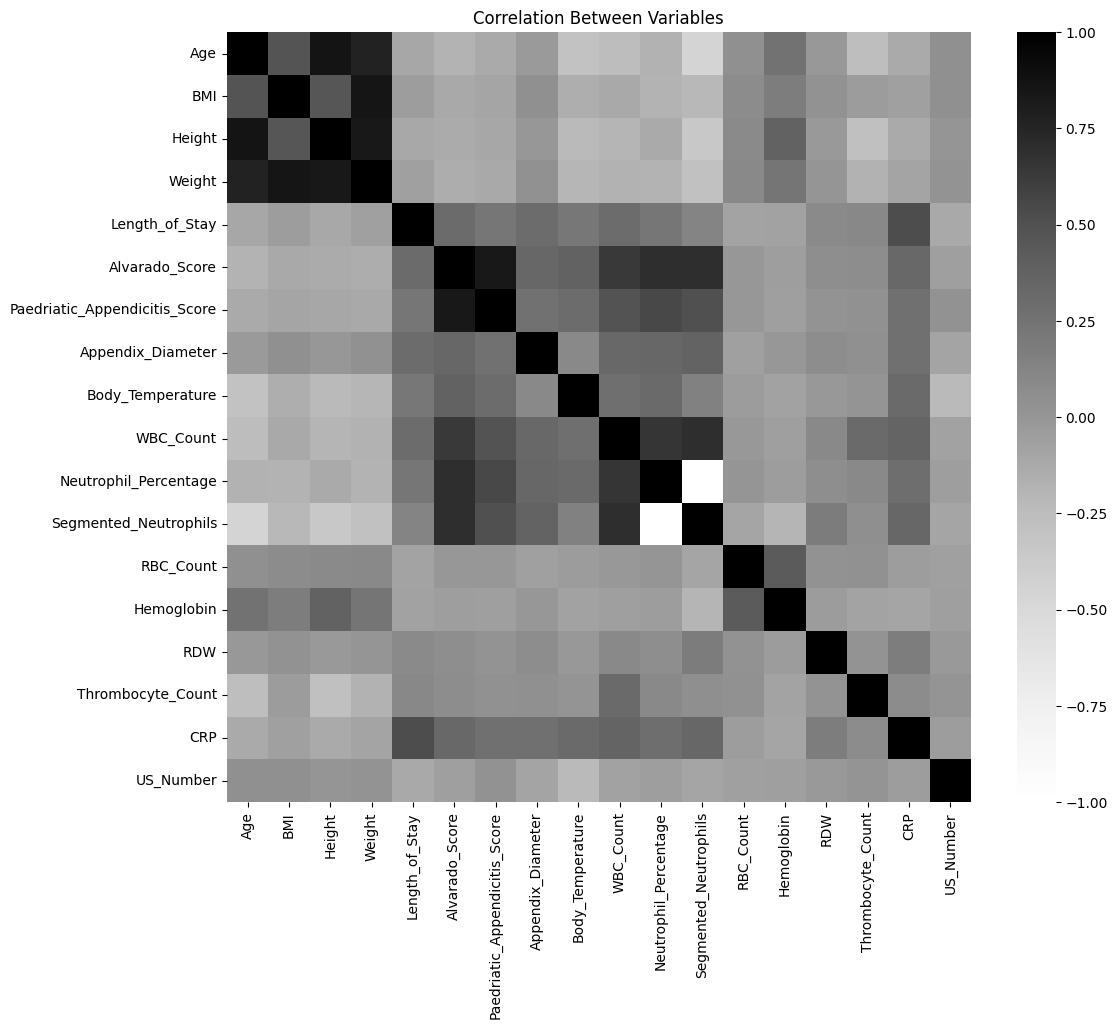

In [19]:

# Descriptive statistics
display(df.describe())

# Bar chart
import matplotlib.pyplot as plt
df["Diagnosis"].value_counts().plot(
    kind="bar",
    color=["lightgreen", "purple"])
plt.title("Distribution of Diagnoses")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

# Heatmap packages
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlations (not target)
numeric_df = df.drop(columns=["Diagnosis"]).select_dtypes(include="number")
correlation = numeric_df.corr()

# Create heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    correlation,
    cmap="Greys",
    vmin=-1,
    vmax=1
)
plt.title("Correlation Between Variables")
plt.show()


The visualizations show an imbalance in the target. This is a consideration for our machine learning project, and this issue will require class balancing fixes, depending on our model.

The correlation matrix shows a distinct pattern of certain demographics and medical measurements being correlated. Many of these correlations are expected. Others may be worth investigating.

### 5. Data Quality

Now the data will be checked for missing values, impossible values, and other possible issues.

In [20]:
# Missingness
print("Missing Values:")
print(df.isnull().sum())


# Value ranges
print("\nRanges:")
display(df.describe().loc[["min", "max"]])

Missing Values:
Age                                   1
BMI                                  27
Sex                                   2
Height                               26
Weight                                3
Length_of_Stay                        4
Management                            1
Severity                              1
Diagnosis_Presumptive                 2
Diagnosis                             2
Alvarado_Score                       52
Paedriatic_Appendicitis_Score        52
Appendix_on_US                        5
Appendix_Diameter                   284
Migratory_Pain                        9
Lower_Right_Abd_Pain                  8
Contralateral_Rebound_Tenderness     15
Coughing_Pain                        16
Nausea                                8
Loss_of_Appetite                     10
Body_Temperature                      7
WBC_Count                             6
Neutrophil_Percentage               103
Segmented_Neutrophils               728
Neutrophilia            

,Age,BMI,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP,US_Number
min,0.00,7.827983,53.0,3.96,1.0,0.0,0.0,2.7,26.9,2.6,27.2,32.0,3.62,8.2,11.2,91.0,0.0,1.0
max,18.36,38.156221,192.0,103.00,28.0,10.0,10.0,17.0,40.2,37.7,97.7,91.0,14.00,36.0,86.9,708.0,365.0,992.0


The data has a lot of missing values and quality issues.

**Possible Preprocessing**
To deal with missing values, imputation may be necessary. Various machine learning models like XGboost also can deal with missing values well. I see some unusually small values, however, if babies and newborns were included in this data then it could be correct. I also need to deal with class imbalance issues via SMOTE or other methods.Diagnoses target is correct as it only has 2 possibilities. Therefore, my binary classification is definitely possible.

### 6. Plan

My machine learning model will utilize various patient data to predict whether a child has appendicitis or not. This will help find connections to appendicitis and help in its detection sooner. The binary variable will be "appendicitis" or "no appendicitis" predicted from 57 features. For a metric, I believe recall will best capture all children who have appendicitis. Precision will also similarly help us determine how often our model is right. Accuracy will be off due to class imbalance.